In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
os.chdir("/content/drive/MyDrive/ColabNotebooks/34132_brain_tumour_classification/")

In [3]:
import pandas as pd
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import Dataset , DataLoader
from torchvision import transforms
from torchvision.io import read_image
from torchvision.models.swin_transformer import swin_s
import torch.nn.functional as F
from torchvision.utils import make_grid

In [4]:
print(torch.__version__)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

2.5.1+cu121
cuda:0


In [5]:
path = "/content/drive/MyDrive/ColabNotebooks/34132_brain_tumour_classification/images/"


data = {"imgpath": [] , "labels": [] }

category = os.listdir(path)
print(category)
for folder in category:
    folderpath = os.path.join(path , folder)
    filelist = os.listdir(folderpath)
    for file in filelist:
        fpath = os.path.join(folderpath, file)
        data["imgpath"].append(fpath)
        data["labels"].append(folder)


df = pd.DataFrame(data)


#Convert labels to numbers
lb = LabelEncoder()
df['encoded_labels'] = lb.fit_transform(df['labels'])


print("-------------Fetch files into a data frame-----------")
print(df)
print("-------------Path to an image file------------------")
print(df.loc[175]['imgpath'])
print("-----------Number of images per category--------------")
print(df.labels.value_counts())

['No_Tumor', 'Tumor']
-------------Fetch files into a data frame-----------
                                               imgpath    labels  \
0    /content/drive/MyDrive/ColabNotebooks/34132_br...  No_Tumor   
1    /content/drive/MyDrive/ColabNotebooks/34132_br...  No_Tumor   
2    /content/drive/MyDrive/ColabNotebooks/34132_br...  No_Tumor   
3    /content/drive/MyDrive/ColabNotebooks/34132_br...  No_Tumor   
4    /content/drive/MyDrive/ColabNotebooks/34132_br...  No_Tumor   
..                                                 ...       ...   
620  /content/drive/MyDrive/ColabNotebooks/34132_br...     Tumor   
621  /content/drive/MyDrive/ColabNotebooks/34132_br...     Tumor   
622  /content/drive/MyDrive/ColabNotebooks/34132_br...     Tumor   
623  /content/drive/MyDrive/ColabNotebooks/34132_br...     Tumor   
624  /content/drive/MyDrive/ColabNotebooks/34132_br...     Tumor   

     encoded_labels  
0                 0  
1                 0  
2                 0  
3                 0

In [6]:
train_df, valid_df = train_test_split(df,  train_size= 0.80 , shuffle=True, random_state=124)
train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)

print("_____________Dataset on Training______________")
print(train_df.head(5))
print(train_df.shape)
print("_____________Dataset on Testing______________")
print(valid_df.head(5))
print(valid_df.shape)

_____________Dataset on Training______________
                                             imgpath    labels  encoded_labels
0  /content/drive/MyDrive/ColabNotebooks/34132_br...     Tumor               1
1  /content/drive/MyDrive/ColabNotebooks/34132_br...  No_Tumor               0
2  /content/drive/MyDrive/ColabNotebooks/34132_br...     Tumor               1
3  /content/drive/MyDrive/ColabNotebooks/34132_br...  No_Tumor               0
4  /content/drive/MyDrive/ColabNotebooks/34132_br...  No_Tumor               0
(500, 3)
_____________Dataset on Testing______________
                                             imgpath    labels  encoded_labels
0  /content/drive/MyDrive/ColabNotebooks/34132_br...     Tumor               1
1  /content/drive/MyDrive/ColabNotebooks/34132_br...  No_Tumor               0
2  /content/drive/MyDrive/ColabNotebooks/34132_br...  No_Tumor               0
3  /content/drive/MyDrive/ColabNotebooks/34132_br...     Tumor               1
4  /content/drive/MyDrive/Col

In [7]:
from torchvision.transforms import v2

In [8]:
image_transforms = {
    'train': transforms.Compose([
        transforms.v2.RGB(),
        transforms.RandomResizedCrop(size=256, scale=(0.8, 1.0)),
        transforms.RandomRotation(degrees=15),
        transforms.RandomHorizontalFlip(),
        transforms.CenterCrop(size=224),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ]),
    'valid': transforms.Compose([
        transforms.v2.RGB(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ]),

}

In [9]:
class brain_tumour_Dataset(Dataset):
    def __init__(self, img_data,transform=None):
        self.transform = transform
        self.img_data = img_data

    def __len__(self):
        return len(self.img_data)

    def __getitem__(self, index):
        img_name = self.img_data.loc[index]['imgpath']
        imge = Image.open(img_name)
        image = imge.resize((224,224))
        label = torch.tensor(self.img_data.loc[index]['encoded_labels'])

        if self.transform is not None:
            image = self.transform(image)

        return image, label


training_data = brain_tumour_Dataset(train_df, image_transforms['train'])
validatin_data = brain_tumour_Dataset(valid_df, image_transforms['valid'])

print("okey")

okey


In [10]:
train_batch_size = 20
val_batch_size = 10

train_dataloader = DataLoader(training_data, batch_size=train_batch_size, shuffle=True)
test_dataloader = DataLoader(validatin_data, batch_size=val_batch_size , shuffle=True)

print(">> Number of Train Data : {} -- Batch Size : {} -- Number of Batch : {} ".format(len(train_dataloader.dataset) , train_batch_size , len(train_dataloader)))
print(">> Number of Validiation Data : {} -- Batch Size : {} -- Number of Batch : {} ".format(len(test_dataloader.dataset) , val_batch_size , len(test_dataloader)))
onebatch = iter(train_dataloader)
train_features, train_labels = next(onebatch)

testbatch = iter(test_dataloader)
test_features, test_labels = next(testbatch)

print("----------Batch Shape--------")
print(f"Feature batch shape: {train_features.size()}")
print("----------Labels Shape--------")
print(f"Labels batch shape: {train_labels.size()}")

print(f"Test batch shape: {test_features.size()}")
print("----------Labels Shape--------")
print(f"Labels batch shape: {test_labels.size()}")

>> Number of Train Data : 500 -- Batch Size : 20 -- Number of Batch : 25 
>> Number of Validiation Data : 125 -- Batch Size : 10 -- Number of Batch : 13 
----------Batch Shape--------
Feature batch shape: torch.Size([20, 3, 224, 224])
----------Labels Shape--------
Labels batch shape: torch.Size([20])
Test batch shape: torch.Size([10, 3, 224, 224])
----------Labels Shape--------
Labels batch shape: torch.Size([10])


In [11]:
print(train_labels)

tensor([1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0])


In [12]:
print(test_labels)

tensor([0, 1, 0, 0, 1, 0, 1, 1, 0, 1])


In [13]:
import torch.nn as nn
import torch.optim as optim

# Freeze the Swin Transformer model as before
model = swin_s(pretrained=True)
for param in model.parameters():
    param.requires_grad = False

# Get the number of input features to the classification head
n_inputs = model.head.in_features

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Swin_S_Weights.IMAGENET1K_V1`. You can also use `weights=Swin_S_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [14]:
n_inputs

768

## Model - CNN with RNN

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super(Attention, self).__init__()
        self.attn_weights = nn.Linear(hidden_dim * 2, 1)  # Bidirectional output = hidden_dim * 2

    def forward(self, rnn_output):
        # rnn_output: [batch_size, seq_length, hidden_dim * 2]
        weights = torch.softmax(self.attn_weights(rnn_output), dim=1)  # Shape: [batch_size, seq_length, 1]
        # Apply attention weights to the RNN output
        context_vector = torch.sum(weights * rnn_output, dim=1)  # Shape: [batch_size, hidden_dim * 2]
        return context_vector


In [ ]:
class CNNRNNModel(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=128, output_dim=2, num_layers=2):
        super(CNNRNNModel, self).__init__()

        # CNN Layers for feature extraction
        self.conv_layers = nn.Sequential(
            nn.Conv2d(input_dim, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))  # Output size: [batch_size, 64, 1, 1]
        )

        # LSTM Layer
        self.lstm = nn.LSTM(
            input_size=64,  # CNN output feature size
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )

        # GRU Layer
        self.gru = nn.GRU(
            input_size=hidden_dim * 2,  # Bidirectional LSTM output
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )

        # Attention Mechanism
        self.attn = Attention(hidden_dim)

        # Fully connected layer for binary classification
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 512),  # Bidirectional GRU output
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, output_dim)  # Final output layer
        )

    def forward(self, x):
        # Reshape input to 4D for CNN: [batch_size, channels, height, width]
        x = x.view(x.size(0), x.size(1), 1, 1)  # Assuming x is [batch_size, 768]

        # Pass through CNN layers
        cnn_out = self.conv_layers(x)  # Shape: [batch_size, 64, 1, 1]
        cnn_out = cnn_out.view(cnn_out.size(0), 1, -1)  # Reshape to [batch_size, seq_len=1, feature_dim=64]

        # Pass through LSTM
        lstm_out, _ = self.lstm(cnn_out)  # Shape: [batch_size, seq_len, hidden_dim * 2]

        # Pass through GRU
        gru_out, _ = self.gru(lstm_out)  # Shape: [batch_size, seq_len, hidden_dim * 2]

        # Apply attention mechanism
        attn_out = self.attn(gru_out)  # Shape: [batch_size, hidden_dim * 2]

        # Pass through fully connected layers
        out = self.fc(attn_out)  # Shape: [batch_size, output_dim]
        return out

In [14]:
model.head = CNNRNNModel(input_dim=768, hidden_dim=128, output_dim=2, num_layers=2)

# Move model to the device
model = model.to(device)

# Define loss and optimizer
criterion = nn.CrossEntropyLoss().to(device)
optimizer = optim.AdamW(model.head.parameters(), lr=0.001)

print("CNN-RNN model with LSTM, GRU, and attention setup complete!")

CNN-RNN model with LSTM, GRU, and attention setup complete!


In [15]:
model.eval()

SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=96, out_features=288, bias=True)
          (proj): Linear(in_features=96, out_features=96, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=96, out_features=384, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=384, out_features=96, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock(
       

## Training

In [16]:
from tqdm import tqdm

In [17]:
def train_model(model, optimizer, criterion, data_loader, device):
    model.train()
    running_loss = 0.0
    correct = 0

    # Progress bar
    pbar = tqdm(data_loader, desc="Training", leave=False)

    for inputs, labels in pbar:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == labels).sum().item()
        running_loss += loss.item() * inputs.size(0)

    avg_train_loss = running_loss / len(data_loader.dataset)
    avg_train_acc = (correct / len(data_loader.dataset)) * 100
    print(">>> Train loss: {:.4f} ---- Train Accuracy: {:.2f}%".format(avg_train_loss, avg_train_acc))

    return avg_train_loss, avg_train_acc

## Testing

In [18]:
def test_model(model, criterion, data_loader, device):
    model.eval()
    val_loss = 0.0
    correct = 0

    # Progress bar
    pbar = tqdm(data_loader, desc="Validation", leave=False)

    with torch.no_grad():
        for inputs, labels in pbar:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(data_loader.dataset)
    avg_val_acc = (correct / len(data_loader.dataset)) * 100
    print(">>> Validation loss: {:.4f} ---- Validation Accuracy: {:.2f}%".format(avg_val_loss, avg_val_acc))

    return avg_val_loss, avg_val_acc


In [19]:
num_epochs = 100

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(num_epochs):
    print(f"------------------ Epoch {epoch+1}/{num_epochs} ------------------")

    T_loss, T_acc = train_model(model, optimizer, criterion, train_dataloader, device)
    V_loss, V_acc = test_model(model, criterion, test_dataloader, device)

    history["train_loss"].append(T_loss)
    history["train_acc"].append(T_acc)
    history["val_loss"].append(V_loss)
    history["val_acc"].append(V_acc)


------------------ Epoch 1/100 ------------------


>>> Train loss: 0.6847 ---- Train Accuracy: 53.40%


>>> Validation loss: 0.6319 ---- Validation Accuracy: 63.20%
------------------ Epoch 2/100 ------------------


>>> Train loss: 0.6196 ---- Train Accuracy: 67.20%


>>> Validation loss: 0.5080 ---- Validation Accuracy: 74.40%
------------------ Epoch 3/100 ------------------


...

>>> Validation loss: 0.2937 ---- Validation Accuracy: 88.00%
------------------ Epoch 99/100 ------------------


>>> Train loss: 0.3881 ---- Train Accuracy: 83.20%


>>> Validation loss: 0.3016 ---- Validation Accuracy: 88.00%
------------------ Epoch 100/100 ------------------


>>> Train loss: 0.3511 ---- Train Accuracy: 85.20%


>>> Validation loss: 0.3187 ---- Validation Accuracy: 85.60%


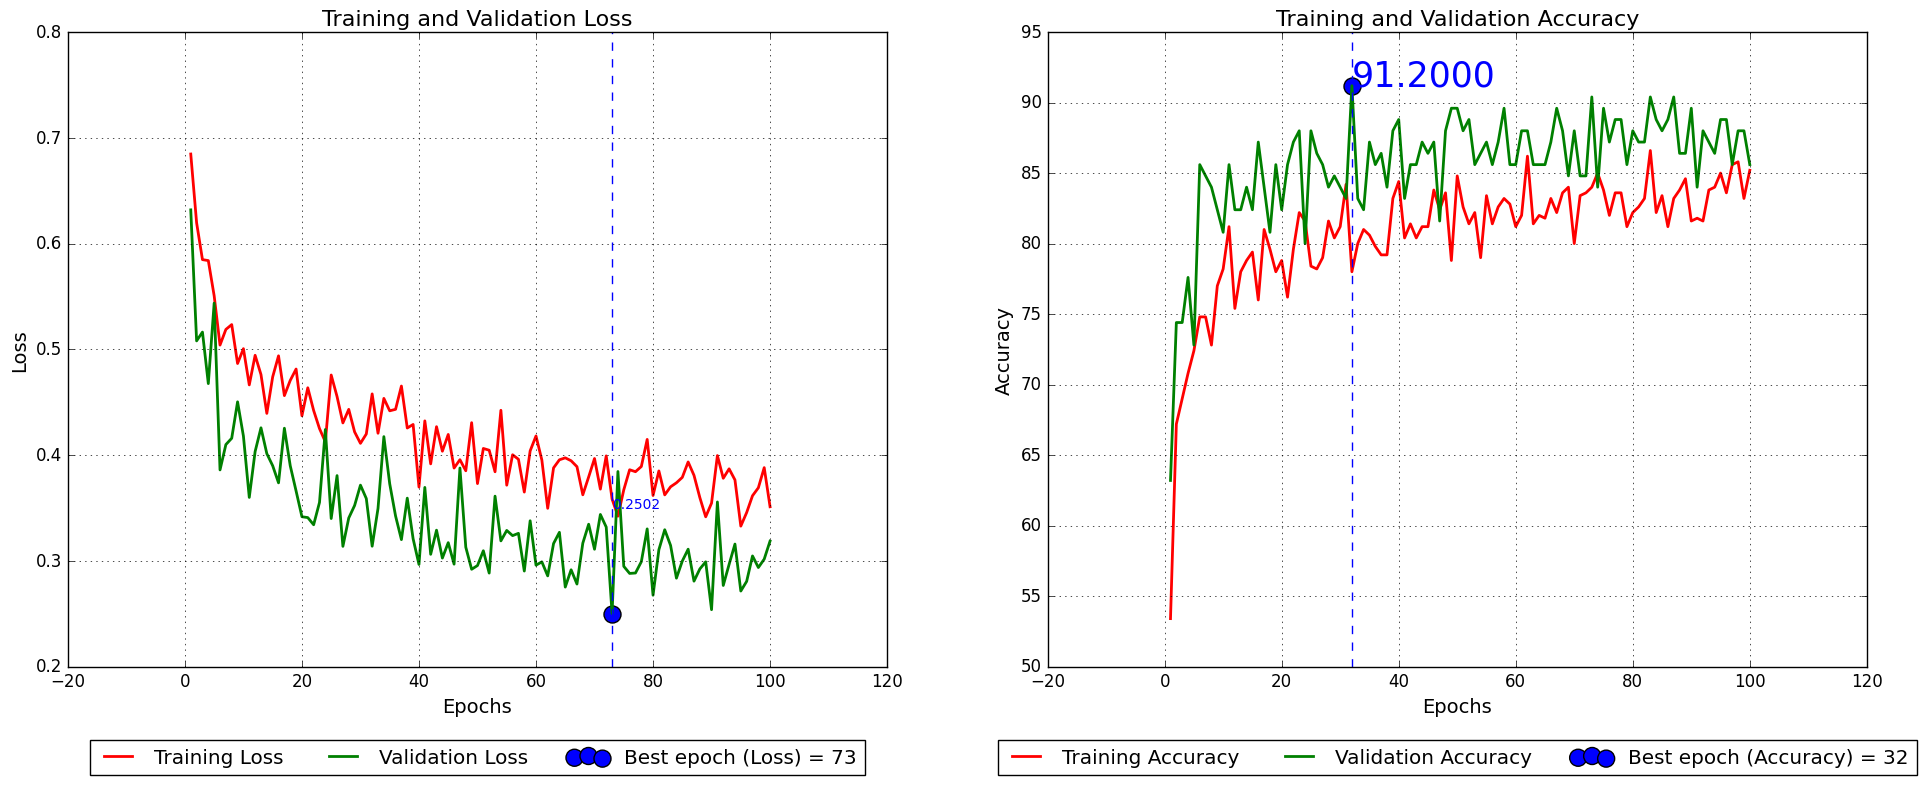

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming `history` is a dictionary containing training stats
tr_acc = history["train_acc"]
tr_loss = history["train_loss"]
val_acc = history["val_acc"]
val_loss = history["val_loss"]

# Find the epoch with the lowest validation loss and highest validation accuracy
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]

Epochs = [i + 1 for i in range(len(tr_acc))]
loss_label = f'Best epoch (Loss) = {index_loss + 1}'
acc_label = f'Best epoch (Accuracy) = {index_acc + 1}'

# Plotting
plt.figure(figsize=(20, 8))
plt.style.use('classic')

# Plot Training and Validation Loss
plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r-', label='Training Loss', linewidth=2)
plt.plot(Epochs, val_loss, 'g-', label='Validation Loss', linewidth=2)
plt.scatter(index_loss + 1, val_lowest, s=150, c='blue', label=loss_label)
plt.axvline(index_loss + 1, color='blue', linestyle='--', linewidth=1)
plt.text(index_loss + 1, val_lowest + 0.1, f'{val_lowest:.4f}', color='blue', fontsize=10)
plt.title('Training and Validation Loss', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend()
plt.grid()

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4)

# Plot Training and Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r-', label='Training Accuracy', linewidth=2)
plt.plot(Epochs, val_acc, 'g-', label='Validation Accuracy', linewidth=2)
plt.scatter(index_acc + 1, acc_highest, s=150, c='blue', label=acc_label)
plt.axvline(index_acc + 1, color='blue', linestyle='--', linewidth=1)
plt.text(index_acc + 1, acc_highest + 0.01, f'{acc_highest:.4f}', color='blue', fontsize=25)
plt.title('Training and Validation Accuracy', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend()
plt.grid()

# Add a single legend below both subplots
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4)

# Final Layout Adjustment and Show Plot
plt.tight_layout()
plt.show()

In [25]:
# Save the model weights
torch.save(model.state_dict(), 'cnn_rnn_swin_transformer_model_weights.pth')

In [26]:
model.load_state_dict(torch.load('cnn_rnn_swin_transformer_model_weights.pth'))
model = model.to(device)

<ipython-input-26-efcd57aa6f06>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('cnn_rnn_swin_transformer_model_weights.pth'))


## Metrics and evaluation

In [27]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(all_labels, all_preds, class_names):
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

In [ ]:
import torch
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

In [29]:
def evaluate_model_with_cm(model, data_loader, device):
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for data in data_loader:
            inputs, labels = data
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    # Calculating metrics
    acc_swin = accuracy_score(all_labels, all_preds)
    prec_swin = precision_score(all_labels, all_preds)
    rec_swin = recall_score(all_labels, all_preds)
    f1_swin = f1_score(all_labels, all_preds)

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    tn, fp, fn, tp = cm.ravel()

    # Sensitivity and Specificity
    sensitivity_swin = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity_swin = tn / (tn + fp) if (tn + fp) > 0 else 0

    # Print metrics
    print("Accuracy:", acc_swin)
    print("Precision:", prec_swin)
    print("Recall:", rec_swin)
    print("F1 Score:", f1_swin)
    print("Sensitivity:", sensitivity_swin)
    print("Specificity:", specificity_swin)
    print("")

    # Classification report
    report = classification_report(all_labels, all_preds, target_names=['Tumour', 'No Tumour'])
    print(report)

    # Save metrics to CSV
    metrics = {
        "Accuracy": [acc_swin],
        "Precision": [prec_swin],
        "Recall": [rec_swin],
        "F1 Score": [f1_swin],
        "Sensitivity": [sensitivity_swin],
        "Specificity": [specificity_swin]
    }
    metrics_df = pd.DataFrame(metrics)
    metrics_df.to_csv("model_evaluation_metrics_swin_cnn_rnn.csv", index=False)

    # Plot confusion matrix
    plot_confusion_matrix(all_labels, all_preds, class_names=['Tumour', 'No Tumour'])

    return report

Accuracy: 0.856
Precision: 0.9444444444444444
Recall: 0.7727272727272727
F1 Score: 0.85
Sensitivity: 0.7727272727272727
Specificity: 0.9491525423728814

              precision    recall  f1-score   support

      Tumour       0.79      0.95      0.86        59
   No Tumour       0.94      0.77      0.85        66

    accuracy                           0.86       125
   macro avg       0.87      0.86      0.86       125
weighted avg       0.87      0.86      0.86       125



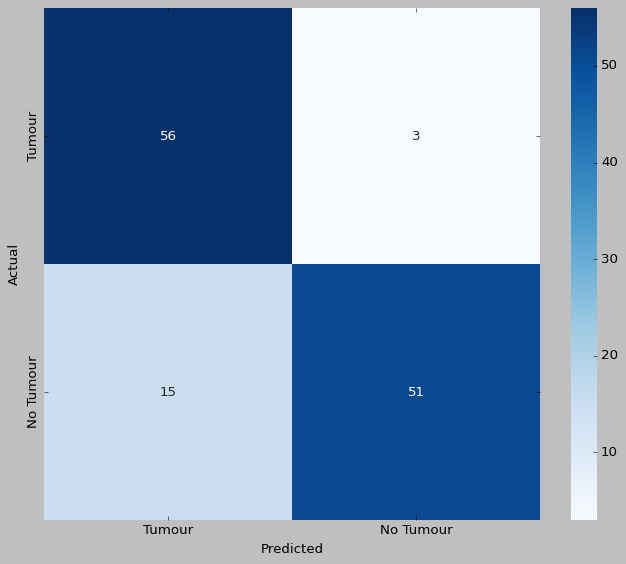

In [30]:
classification_report = evaluate_model_with_cm(model, test_dataloader, device)